<a href="https://colab.research.google.com/github/rickzzim/aula6/blob/main/Aula6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

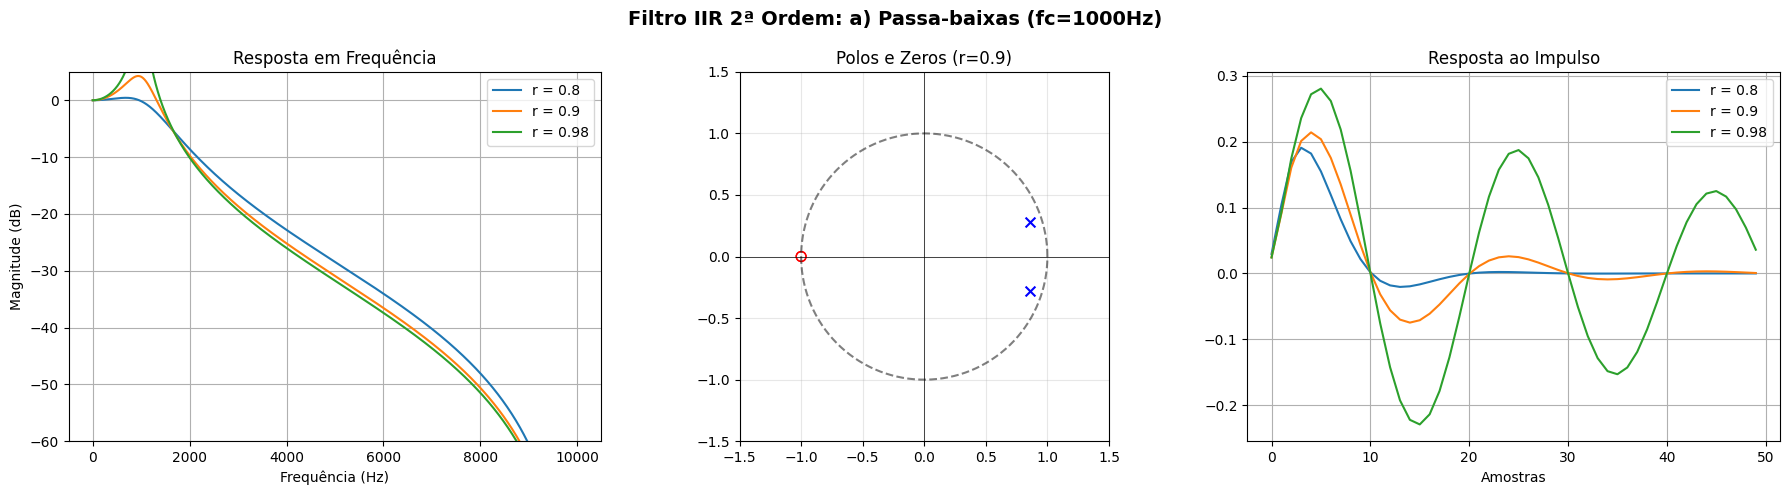

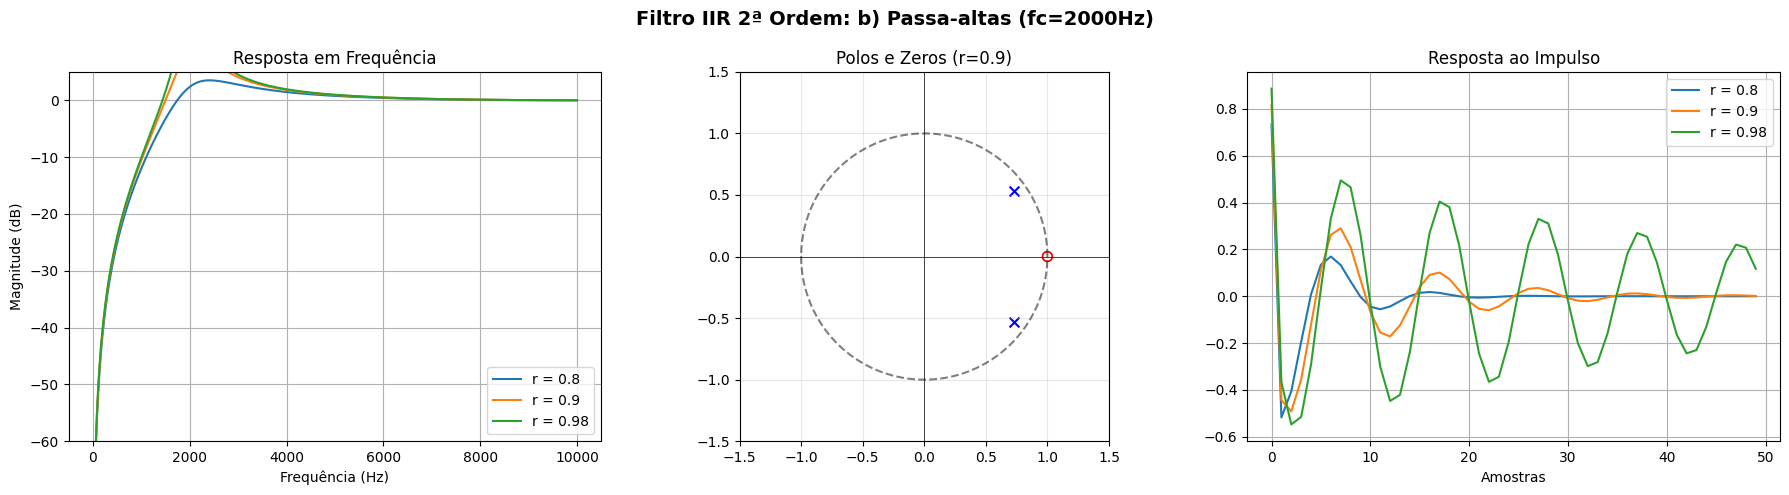

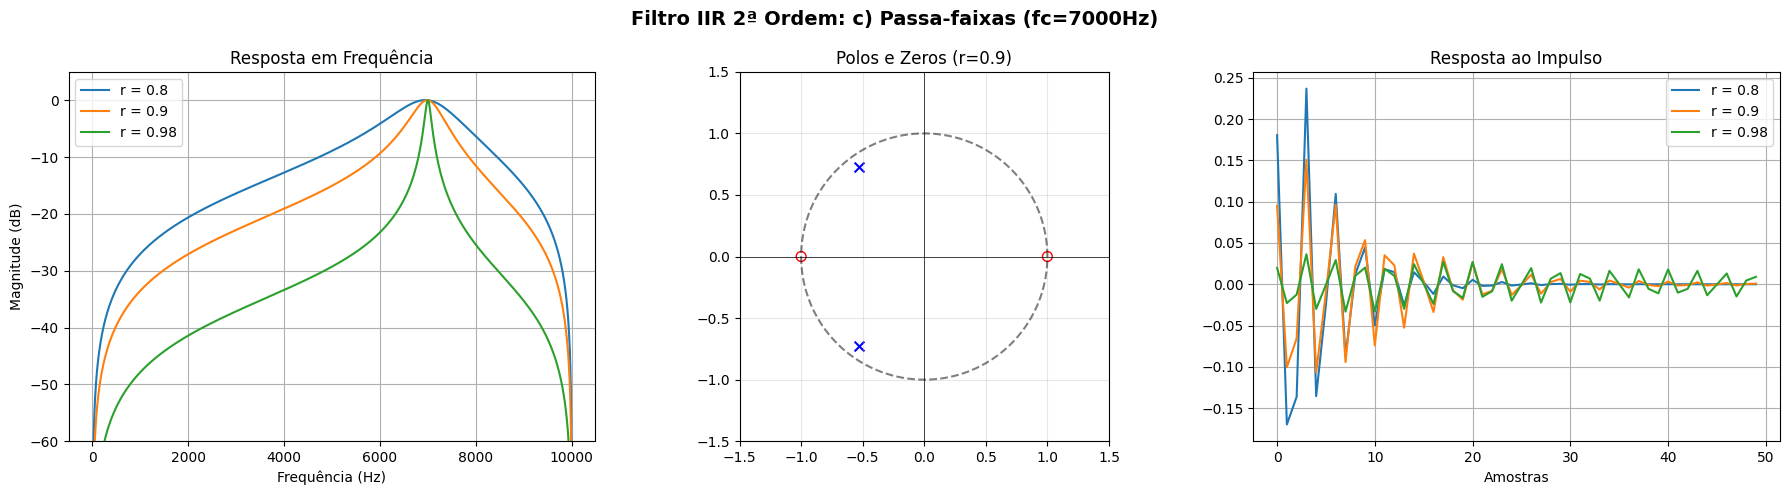

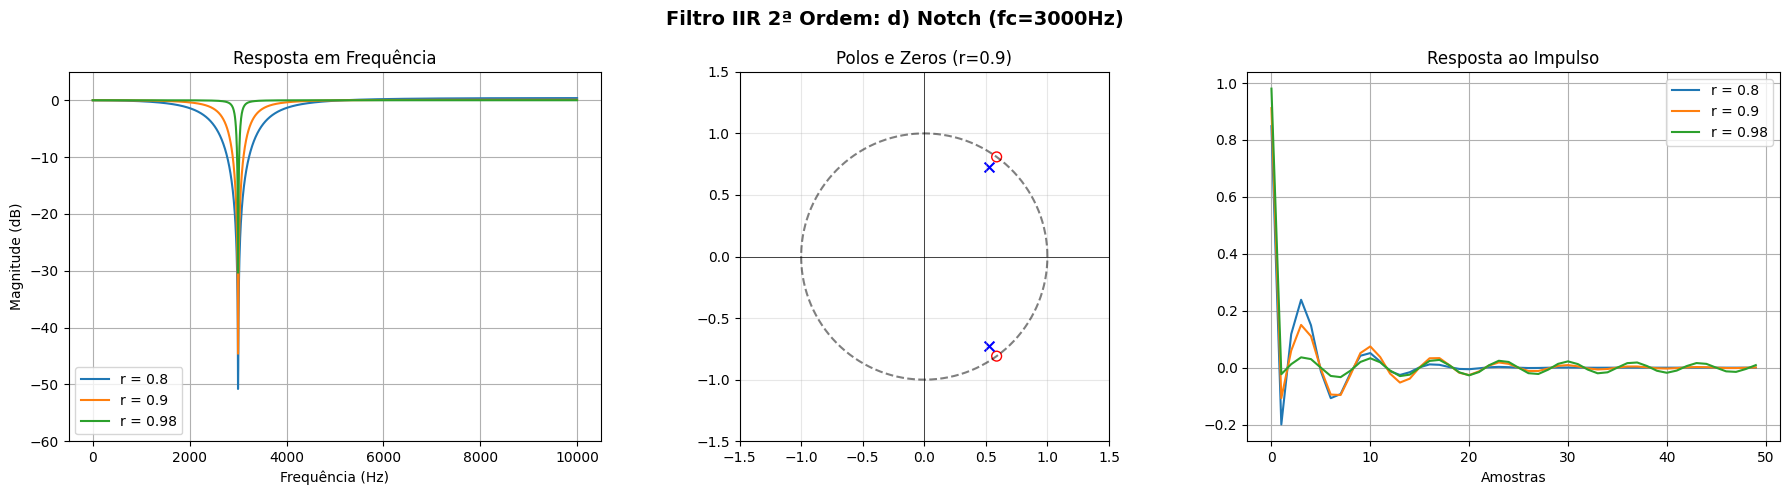

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Parâmetros gerais
fs = 20000
r_values = [0.8, 0.9, 0.98] # Variação do parâmetro r

# Função auxiliar para o diagrama de polos e zeros
def plot_zplane(b, a, ax, title):
    z, p, _ = signal.tf2zpk(b, a)
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.scatter(np.real(z), np.imag(z), s=50, facecolors='none', edgecolors='r', label='Zeros')
    ax.scatter(np.real(p), np.imag(p), s=50, color='b', marker='x', label='Polos')
    ax.set_title(title)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# 1. Definição dos blocos de 2ª ordem
filtros_q1 = {
    'a) Passa-baixas (fc=1000Hz)': {'fc': 1000, 'type': 'lp'},
    'b) Passa-altas (fc=2000Hz)': {'fc': 2000, 'type': 'hp'},
    'c) Passa-faixas (fc=7000Hz)': {'fc': 7000, 'type': 'bp'},
    'd) Notch (fc=3000Hz)': {'fc': 3000, 'type': 'notch'}
}

for nome, params in filtros_q1.items():
    wc = 2 * np.pi * params['fc'] / fs

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Filtro IIR 2ª Ordem: {nome}", fontsize=14, fontweight='bold')

    for i, r in enumerate(r_values):
        # Denominador comum (polos)
        a = [1, -2*r*np.cos(wc), r**2]

        # Numerador (zeros) depende do tipo
        if params['type'] == 'lp':
            b = [1, 2, 1] # Zeros em z = -1
        elif params['type'] == 'hp':
            b = [1, -2, 1] # Zeros em z = 1
        elif params['type'] == 'bp':
            b = [1, 0, -1] # Zeros em z = 1 e z = -1
        elif params['type'] == 'notch':
            b = [1, -2*np.cos(wc), 1] # Zeros na mesma frequência wc sobre o círculo

        # Normalização de ganho (G) no pico/banda de passagem
        w, h = signal.freqz(b, a, worN=1024)
        if params['type'] == 'lp': idx = 0
        elif params['type'] == 'hp': idx = -1
        elif params['type'] == 'bp': idx = np.argmin(np.abs(w - wc))
        elif params['type'] == 'notch': idx = 0
        G = 1 / np.abs(h[idx])
        b = [coef * G for coef in b]

        # Resposta em frequência
        w, h = signal.freqz(b, a, worN=2048, fs=fs)
        axes[0].plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'r = {r}')

        # Plot polos e zeros apenas para r=0.9 para visualização clara
        if r == 0.9:
            plot_zplane(b, a, axes[1], f"Polos e Zeros (r={r})")

        # Resposta ao impulso
        impulse = np.zeros(50); impulse[0] = 1
        h_n = signal.lfilter(b, a, impulse)
        axes[2].plot(h_n, label=f'r = {r}')

    axes[0].set_title("Resposta em Frequência")
    axes[0].set_xlabel("Frequência (Hz)"); axes[0].set_ylabel("Magnitude (dB)")
    axes[0].set_ylim([-60, 5]); axes[0].grid(True); axes[0].legend()

    axes[2].set_title("Resposta ao Impulso")
    axes[2].set_xlabel("Amostras"); axes[2].grid(True); axes[2].legend()

    plt.tight_layout()
    plt.show()

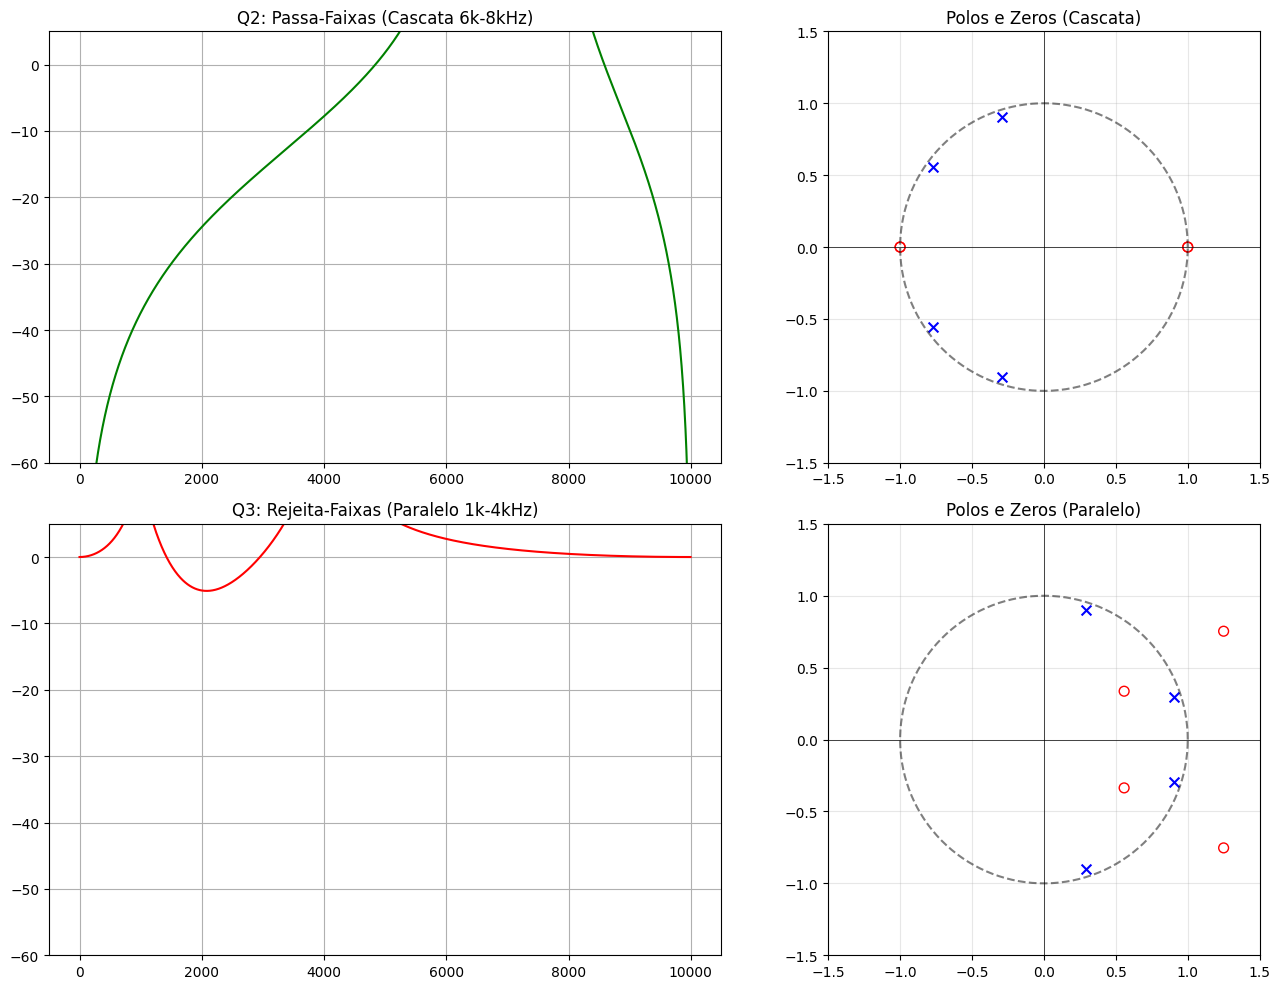

In [2]:
# 2. Cascata (Passa-Faixas 6k a 8k) e 3. Paralelo (Rejeita-Faixas 1k a 4k)
r_opt = 0.95 # Escolha de um r elevado para boa seletividade

# --- Questão 2: Passa-Faixas (Cascata HP 6000 Hz * LP 8000 Hz) ---
wc_hp = 2 * np.pi * 6000 / fs
a_hp = [1, -2*r_opt*np.cos(wc_hp), r_opt**2]
b_hp = [1, -2, 1] # Zeros HP
G_hp = 1 / np.abs(signal.freqz(b_hp, a_hp, worN=[np.pi])[1][0])
b_hp = [coef * G_hp for coef in b_hp]

wc_lp = 2 * np.pi * 8000 / fs
a_lp = [1, -2*r_opt*np.cos(wc_lp), r_opt**2]
b_lp = [1, 2, 1] # Zeros LP
G_lp = 1 / np.abs(signal.freqz(b_lp, a_lp, worN=[0])[1][0])
b_lp = [coef * G_lp for coef in b_lp]

# Cascata (Convolução dos coeficientes)
b_cascata = np.convolve(b_hp, b_lp)
a_cascata = np.convolve(a_hp, a_lp)

# --- Questão 3: Rejeita-Faixas (Paralelo LP 1000 Hz + HP 4000 Hz) ---
wc_lp2 = 2 * np.pi * 1000 / fs
a_lp2 = [1, -2*r_opt*np.cos(wc_lp2), r_opt**2]
b_lp2 = [1, 2, 1]
G_lp2 = 1 / np.abs(signal.freqz(b_lp2, a_lp2, worN=[0])[1][0])
b_lp2 = [coef * G_lp2 for coef in b_lp2]

wc_hp2 = 2 * np.pi * 4000 / fs
a_hp2 = [1, -2*r_opt*np.cos(wc_hp2), r_opt**2]
b_hp2 = [1, -2, 1]
G_hp2 = 1 / np.abs(signal.freqz(b_hp2, a_hp2, worN=[np.pi])[1][0])
b_hp2 = [coef * G_hp2 for coef in b_hp2]

# Paralelo (H(z) = H1(z) + H2(z) -> H(z) = (B1*A2 + B2*A1) / (A1*A2))
b_paralelo = np.add(np.convolve(b_lp2, a_hp2), np.convolve(b_hp2, a_lp2))
a_paralelo = np.convolve(a_lp2, a_hp2)

# --- PLOTS COMPARAÇÃO Q2 e Q3 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cascata
w, h_casc = signal.freqz(b_cascata, a_cascata, worN=2048, fs=fs)
axes[0, 0].plot(w, 20 * np.log10(np.abs(h_casc) + 1e-12), 'g')
axes[0, 0].set_title("Q2: Passa-Faixas (Cascata 6k-8kHz)")
axes[0, 0].set_ylim([-60, 5]); axes[0, 0].grid(True)
plot_zplane(b_cascata, a_cascata, axes[0, 1], "Polos e Zeros (Cascata)")

# Paralelo
w, h_par = signal.freqz(b_paralelo, a_paralelo, worN=2048, fs=fs)
axes[1, 0].plot(w, 20 * np.log10(np.abs(h_par) + 1e-12), 'r')
axes[1, 0].set_title("Q3: Rejeita-Faixas (Paralelo 1k-4kHz)")
axes[1, 0].set_ylim([-60, 5]); axes[1, 0].grid(True)
plot_zplane(b_paralelo, a_paralelo, axes[1, 1], "Polos e Zeros (Paralelo)")

plt.tight_layout()
plt.show()

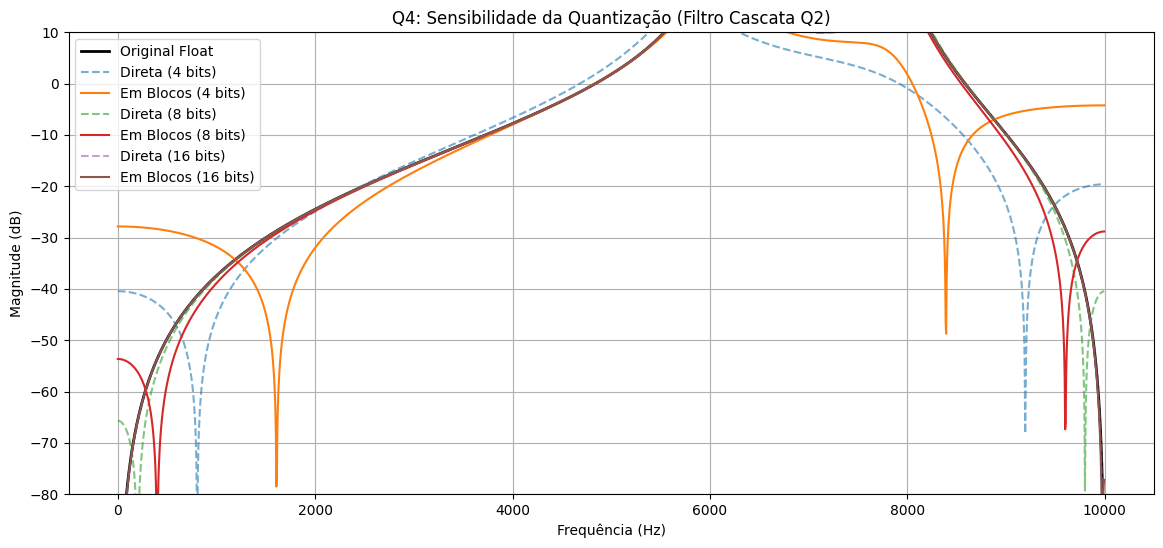

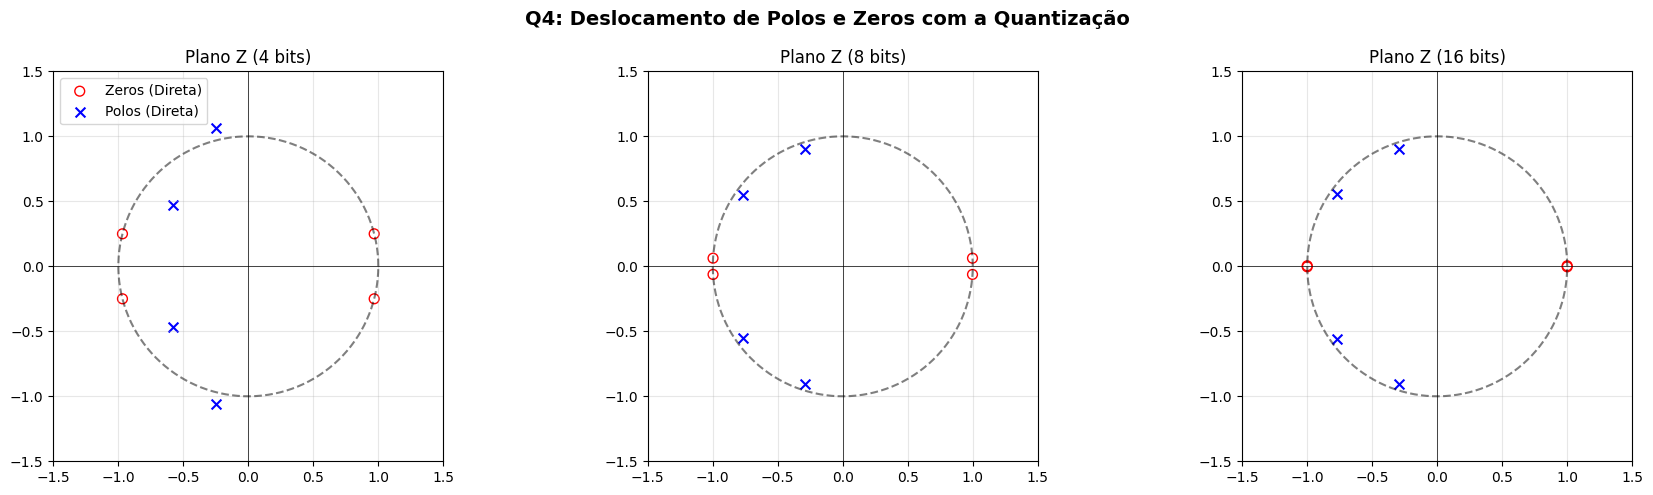

In [4]:
# =====================================================================
# QUESTÃO 4: Sensibilidade da Quantização (CÓDIGO CORRIGIDO)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

bits_list = [4, 8, 16]

def quantize(coefs, bits):
    max_val = np.max(np.abs(coefs))
    if max_val == 0: return coefs
    norm = coefs / max_val
    n_levels = 2**(bits - 1) - 1
    return np.round(norm * n_levels) / n_levels * max_val

# --- 1. Plot da Resposta em Frequência (Magnitude) ---
plt.figure(figsize=(14, 6))
w, h_orig = signal.freqz(b_cascata, a_cascata, worN=2048, fs=fs)
plt.plot(w, 20 * np.log10(np.abs(h_orig) + 1e-12), 'k', lw=2, label="Original Float")

for bits in bits_list:
    # Abordagem 1: Forma Direta Complete
    b_direta_q = quantize(b_cascata, bits)
    a_direta_q = quantize(a_cascata, bits)
    w, h_dir = signal.freqz(b_direta_q, a_direta_q, worN=2048, fs=fs)

    # Abordagem 2: Em Blocos SOS (Second-Order Sections)
    b_hp_q = quantize(b_hp, bits); a_hp_q = quantize(a_hp, bits)
    b_lp_q = quantize(b_lp, bits); a_lp_q = quantize(a_lp, bits)
    b_blocos_q = np.convolve(b_hp_q, b_lp_q)
    a_blocos_q = np.convolve(a_hp_q, a_lp_q)
    w, h_blocos = signal.freqz(b_blocos_q, a_blocos_q, worN=2048, fs=fs)

    plt.plot(w, 20 * np.log10(np.abs(h_dir) + 1e-12), '--', alpha=0.6, label=f"Direta ({bits} bits)")
    plt.plot(w, 20 * np.log10(np.abs(h_blocos) + 1e-12), label=f"Em Blocos ({bits} bits)")

plt.title("Q4: Sensibilidade da Quantização (Filtro Cascata Q2)")
plt.ylim([-80, 10])
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True)
plt.show()


# --- 2. Plot dos Diagramas de Polos e Zeros com Correção de Escala ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Q4: Deslocamento de Polos e Zeros com a Quantização", fontsize=14, fontweight='bold')

for i, bits in enumerate(bits_list):
    ax = axes[i]

    # Extração das raízes para a Forma Direta Quantizada
    b_direta_q = quantize(b_cascata, bits)
    a_direta_q = quantize(a_cascata, bits)
    z_dir, p_dir, _ = signal.tf2zpk(b_direta_q, a_direta_q)

    # Desenho do círculo unitário de referência
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)

    # Plot das raízes quantizadas
    ax.scatter(np.real(z_dir), np.imag(z_dir), s=50, facecolors='none', edgecolors='r', label='Zeros (Direta)')
    ax.scatter(np.real(p_dir), np.imag(p_dir), s=50, color='b', marker='x', label='Polos (Direta)')

    # CORREÇÃO CRUCIAL DE ESCALA: Trava os eixos ao redor do círculo unitário
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])

    ax.set_title(f"Plano Z ({bits} bits)")
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

<>:84: SyntaxWarning: invalid escape sequence '\h'
<>:97: SyntaxWarning: invalid escape sequence '\h'
<>:84: SyntaxWarning: invalid escape sequence '\h'
<>:97: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_18609/1007468831.py:84: SyntaxWarning: invalid escape sequence '\h'
  axes[0].plot(t[:1000], x_rec_foco[:1000], 'b--', label='Recuperado $\hat{x}(t)$', alpha=0.8)
/tmp/ipykernel_18609/1007468831.py:97: SyntaxWarning: invalid escape sequence '\h'
  axes[1].plot(freqs, X_rec_f, 'b', alpha=0.9, label='Recuperado $\hat{x}(t)$')


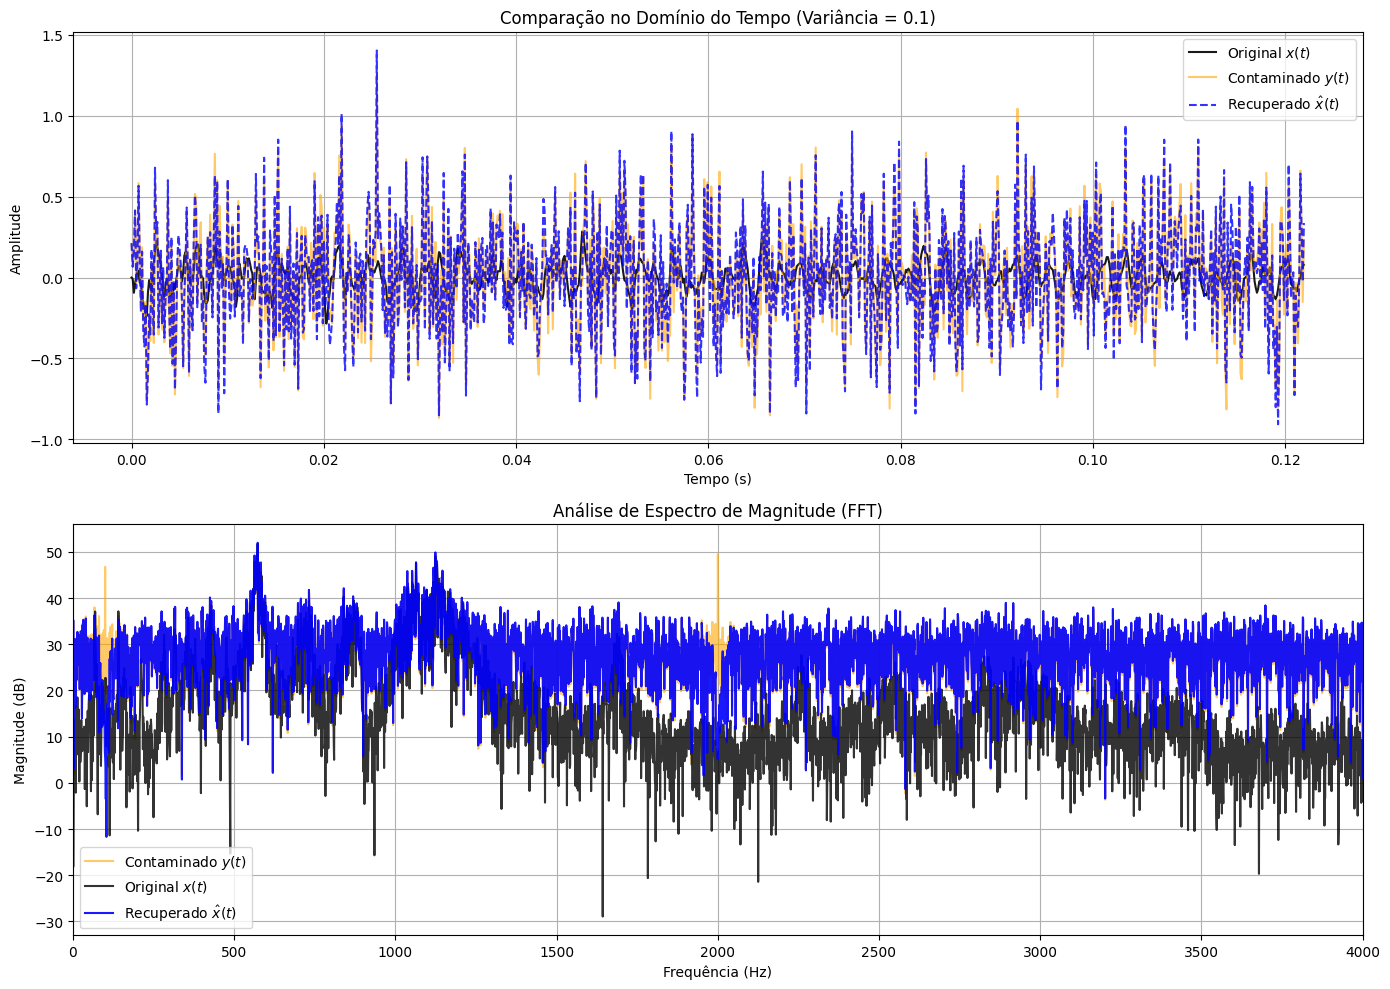

======= MÈTRICAS QUANTITATIVAS OBTIDAS =======
Variância 0.01: SNR = 6.97 dB | MSE = 0.012079
Variância 0.1: SNR = -2.66 dB | MSE = 0.110974
Variância 1.0: SNR = -12.62 dB | MSE = 1.100049

======= CONTROLE DE ÁUDIO (VARIÂNCIA = 0.1) =======
Áudio Original:


Áudio Contaminado:


Áudio Filtrado/Recuperado:


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.io import wavfile
import IPython.display as ipd

# =====================================================================
# QUESTÃO 5: PROCESSAMENTO DIGITAL DO ÁUDIO REAL (handel.wav)
# =====================================================================

# 1. Carregamento do Áudio Real
fs_audio, x_t = wavfile.read('handel.wav')

# Normalização do sinal para float entre -1 e 1
if x_t.dtype != np.float32 and x_t.dtype != np.float64:
    x_t = x_t / np.max(np.abs(x_t))
if len(x_t.shape) > 1:
    x_t = x_t[:, 0]  # Garante canal mono

N = len(x_t)
t = np.arange(N) / fs_audio

# Definição das variâncias do ruído estipuladas no roteiro
variancias = [0.01, 0.1, 1.0]
resultados_sinais = {}
metricas = {}

# Parâmetro r de seletividade fina para os filtros Notch
r_notch = 0.98

for var in variancias:
    # (a) Contaminação do Sinal conforme o modelo matemático do PDF
    # y(t) = x(t) + 0.05*cos(200*pi*t) + 0.075*sin(4000*pi*t) + n(t)
    interf_low = 0.05 * np.cos(200 * np.pi * t)
    interf_high = 0.075 * np.sin(4000 * np.pi * t)

    np.random.seed(42)  # Reprodutibilidade do ruído branco
    ruido_branco = np.random.normal(0, np.sqrt(var), N)

    y_t = x_t + interf_low + interf_high + ruido_branco

    # (c) Projeto do Sistema de Filtragem em Cascata (Notch 100Hz e Notch 2000Hz)
    # Notch 1: Eliminar interferência de 100 Hz (200*pi*t -> 100 Hz)
    wc_100 = 2 * np.pi * 100 / fs_audio
    b_n1 = [1, -2 * np.cos(wc_100), 1]
    a_n1 = [1, -2 * r_notch * np.cos(wc_100), r_notch**2]
    # Ganho de normalização em DC
    G_n1 = 1.0 / np.abs(signal.freqz(b_n1, a_n1, worN=[0])[1][0])
    b_n1 = [coef * G_n1 for coef in b_n1]

    # Notch 2: Eliminar interferência de 2000 Hz (4000*pi*t -> 2000 Hz)
    wc_2000 = 2 * np.pi * 2000 / fs_audio
    b_n2 = [1, -2 * np.cos(wc_2000), 1]
    a_n2 = [1, -2 * r_notch * np.cos(wc_2000), r_notch**2]
    # Ganho de normalização em DC
    G_n2 = 1.0 / np.abs(signal.freqz(b_n2, a_n2, worN=[0])[1][0])
    b_n2 = [coef * G_n2 for coef in b_n2]

    # (d) Processamento do Sinal em Cascata (Filtragem em série)
    sinal_interm = signal.lfilter(b_n1, a_n1, y_t)
    x_recuperado = signal.lfilter(b_n2, a_n2, sinal_interm)

    #Armazenamento dos sinais para plotagem/áudio
    resultados_sinais[var] = {'contaminado': y_t, 'recuperado': x_recuperado}

    # (e) Cálculo das Métricas Quantitativas (MSE e SNR)
    erro_residual = x_t - x_recuperado
    mse = np.mean(erro_residual**2)
    pot_sinal = np.mean(x_t**2)
    snr = 10 * np.log10(pot_sinal / (mse + 1e-12))

    metricas[var] = {'SNR': snr, 'MSE': mse}

# --- GERAÇÃO DOS GRÁFICOS (Exemplo focado em Variância = 0.1) ---
var_foco = 0.1
y_foco = resultados_sinais[var_foco]['contaminado']
x_rec_foco = resultados_sinais[var_foco]['recuperado']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot Domínio do Tempo (Amostra Inicial)
axes[0].plot(t[:1000], x_t[:1000], 'k', label='Original $x(t)$', alpha=0.9)
axes[0].plot(t[:1000], y_foco[:1000], 'orange', label='Contaminado $y(t)$', alpha=0.6)
axes[0].plot(t[:1000], x_rec_foco[:1000], 'b--', label='Recuperado $\hat{x}(t)$', alpha=0.8)
axes[0].set_title(f"Comparação no Domínio do Tempo (Variância = {var_foco})")
axes[0].set_xlabel("Tempo (s)"); axes[0].set_ylabel("Amplitude")
axes[0].legend(); axes[0].grid(True)

# Plot Domínio da Frequência (Espectro por FFT)
freqs = np.linspace(0, fs_audio / 2, 4096)
X_f = 20 * np.log10(np.abs(np.fft.fft(x_t, 8192)[:4096]) + 1e-12)
Y_f = 20 * np.log10(np.abs(np.fft.fft(y_foco, 8192)[:4096]) + 1e-12)
X_rec_f = 20 * np.log10(np.abs(np.fft.fft(x_rec_foco, 8192)[:4096]) + 1e-12)

axes[1].plot(freqs, Y_f, 'orange', alpha=0.6, label='Contaminado $y(t)$')
axes[1].plot(freqs, X_f, 'k', alpha=0.8, label='Original $x(t)$')
axes[1].plot(freqs, X_rec_f, 'b', alpha=0.9, label='Recuperado $\hat{x}(t)$')
axes[1].set_title("Análise de Espectro de Magnitude (FFT)")
axes[1].set_xlabel("Frequência (Hz)"); axes[1].set_ylabel("Magnitude (dB)")
axes[1].set_xlim([0, 4000])  # Foco na região das interferências
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# Exibição das Métricas para conferência
print("======= MÈTRICAS QUANTITATIVAS OBTIDAS =======")
for var in variancias:
    print(f"Variância {var}: SNR = {metricas[var]['SNR']:.2f} dB | MSE = {metricas[var]['MSE']:.6f}")

# Escuta do Áudio no Navegador (Variância de Foco)
print(f"\n======= CONTROLE DE ÁUDIO (VARIÂNCIA = {var_foco}) =======")
print("Áudio Original:")
ipd.display(ipd.Audio(x_t, rate=fs_audio))
print("Áudio Contaminado:")
ipd.display(ipd.Audio(y_foco, rate=fs_audio))
print("Áudio Filtrado/Recuperado:")
ipd.display(ipd.Audio(x_rec_foco, rate=fs_audio))